# Multi-Tool Agent with LangGraph and Groq

This notebook demonstrates how to create a smart agent using **LangGraph** that can use multiple tools to answer questions. We will use **Groq** for the LLM speed and performance.

### Tools Integrated:
1.  **Google Search**: For latest news and real-time information.
2.  **Wikipedia**: For historical data and general knowledge.
3.  **Arxiv**: For searching scientific and research papers.

### Key Concepts:
-   **StateGraph**: Managing conversation state.
-   **ToolNode**: Handling tool execution.
-   **Conditional Edges**: Deciding whether to call a tool or end the conversation.

In [1]:
%pip install -U langchain langchain-community langchain-groq langchain-google-community langgraph arxiv wikipedia google-search-results python-dotenv pydantic

  Attempting uninstall: arxiv
    Found existing installation: arxiv 2.3.1
    Uninstalling arxiv-2.3.1:
      Successfully uninstalled arxiv-2.3.1
Note: you may need to restart the kernel to use updated packages.


### API Key Setup

You need API keys for Groq and Google Search. Ensure you have a `.env` file with `GROQ_API_KEY`, `GOOGLE_API_KEY`, and `GOOGLE_CSE_ID`.


In [2]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Ensure keys are set (User's preferred method)
if not os.getenv("GROQ_API_KEY"):
    print("Warning: GROQ_API_KEY not found in environment")

if not os.getenv("GOOGLE_API_KEY"):
    print("Warning: GOOGLE_API_KEY not found in environment")    

if not os.getenv("GOOGLE_CSE_ID"):
    print("Warning: GOOGLE_CSE_ID not found in environment")    


if not os.getenv("LANGCHAIN_API_KEY"):
    print("Warning: LANGCHAIN_API_KEY not found in environment")    

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Agent-Groq-Llama3" # Name this whatever you want
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"


### Define Tools
We will explicitly define input schemas using Pydantic to ensure the model generates valid inputs.

In [3]:
from langchain_google_community import GoogleSearchAPIWrapper
from langchain_core.tools import Tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper
from pydantic import BaseModel, Field

# Define explicit schemas for robustness
class SearchInput(BaseModel):
    query: str = Field(description="search query to look up on google")

class WikiInput(BaseModel):
    query: str = Field(description="topic to search on wikipedia")

class ArxivInput(BaseModel):
    query: str = Field(description="scientific topic to search on arxiv")

# 1. Google Search Tool
search = GoogleSearchAPIWrapper()
google_search_tool = Tool(
    name="google_search",
    description="Search Google for recent results.",
    func=search.run,
    args_schema=SearchInput
)

# 2. Wikipedia Tool
wikipedia_wrapper = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=1000)
wikipedia_tool = WikipediaQueryRun(
    api_wrapper=wikipedia_wrapper,
    args_schema=WikiInput
)

# 3. Arxiv Tool
arxiv_wrapper = ArxivAPIWrapper(top_k_results=1, doc_content_chars_max=1000)
arxiv_tool = ArxivQueryRun(
    api_wrapper=arxiv_wrapper,
    args_schema=ArxivInput
)

tools = [google_search_tool, wikipedia_tool, arxiv_tool]

In [4]:
wikipedia_tool.invoke("What is machine learning?")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalise to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nML finds application in many fields, including natural language processing, computer vision, speech recognition, email filtering, agriculture, and medicine. The application of ML to business problems is known as predictive analytics.\nStatistics and mathematical optimisation (mathematical programming) methods comprise the foundations of machine learning. Data mining is a related field of study, focusing on exploratory data analysis (EDA) through unsupervised learning.\nFrom a theoretical viewpoint

### Initialize LLM and Bind Tools
We use `openai/gpt-oss-120b` as it is often more reliable for structured tool calling on Groq.

In [10]:
from langchain_groq import ChatGroq

# Switching to llama-3.3-70b-versatile for better tool calling stability
llm = ChatGroq(model="openai/gpt-oss-20b", temperature=0)
llm_with_tools = llm.bind_tools(tools)

### Define Graph Nodes

In [12]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages  # FIXED: Correct import for add_messages
from langchain_core.messages import SystemMessage, HumanMessage
from typing import Annotated, TypedDict

# 1. Define State
class State(TypedDict):
    messages: Annotated[list, add_messages]

# 2. Define Nodes

def chatbot(state: State):
    """
    Primary agent node with System Prompt to prevent XML errors.
    """
    # System message to enforce JSON format
    system_instruction = SystemMessage(content=(
        "You are a helpful assistant. "
        "You have access to tools. "
        "CRITICAL: Do NOT use XML tags like <function> for tool calls. "
        "Use the standard JSON tool calling format provided by the interface. "
        "If you are unsure, default to a normal text response."
    ))
    
    # Prepend system instruction (filtered out by LangGraph history usually, but good to be explicit)
    # We combine it with existing messages
    messages = [system_instruction] + state["messages"]
    return {"messages": [llm_with_tools.invoke(messages)]}

def verify_answer(state: State):
    """
    Verifies the answer against the original question and context.
    """
    print("\n--- 🕵️ VERIFYING ANSWER ---")
    
    messages = state["messages"]
    last_message = messages[-1]
    
    # FIX 1: Find the original user question
    # We loop backwards to find the last 'human' message
    user_question = "Unknown"
    for msg in reversed(messages[:-1]):
        if isinstance(msg, HumanMessage) or (hasattr(msg, "type") and msg.type == "human"):
            user_question = msg.content
            break

    # FIX 2: Updated Prompt with Context
    # We explicitly give the model the Question AND the Answer to compare.
    verify_prompt = (
        "You are a Quality Control Supervisor. \n"
        f"User Question: \"{user_question}\"\n"
        f"AI Answer: \"{last_message.content}\"\n\n"
        "Task:\n"
        "1. Does the AI Answer directly address the User Question?\n"
        "2. Is the answer coherent?\n"
        "3. Ignore minor formatting issues.\n\n"
        "If the answer is helpful and relevant, respond with exactly: VERIFIED\n"
        "If the answer is completely wrong or misses the user's intent, respond with: REJECTED: [Brief Reason]"
    )
    
    response = llm.invoke([HumanMessage(content=verify_prompt)])
    
    print(f"--- RESULT: {response.content} ---")

    if "REJECTED" in response.content:
        return {"messages": [("user", f"Quality Control Feedback: {response.content}. Please fix this.")]}
    
    return {"messages": []}

# 3. Define Missing Routing Logic (This fixes the NameError)

def route_after_chatbot(state: State):
    """Decides if we need to call a tool OR go to verification."""
    last_message = state["messages"][-1]
    
    # If the chatbot wants to use a tool, go to 'tools'
    if last_message.tool_calls:
        return "tools"
    
    # If the chatbot gave a final answer, go to 'verify_answer'
    return "verify_answer"

def route_after_verification(state: State):
    """Decides if the answer was good enough to End."""
    last_message = state["messages"][-1]
    
    # If the last message is a HumanMessage (our critique), verification failed.
    # Loop back to chatbot to fix it.
    if isinstance(last_message, HumanMessage) or (hasattr(last_message, "type") and last_message.type == "human"):
        return "chatbot"
        
    # Otherwise (it's still the AI message), we are done.
    return END

# 4. Build Graph

graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools))
graph_builder.add_node("verify_answer", verify_answer)

# Edges
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("tools", "chatbot")

graph_builder.add_conditional_edges(
    "chatbot",
    route_after_chatbot,
    {"tools": "tools", "verify_answer": "verify_answer"}
)

graph_builder.add_conditional_edges(
    "verify_answer",
    route_after_verification,
    {"chatbot": "chatbot", END: END}
)

graph = graph_builder.compile()
print("Graph compiled successfully!")

Graph compiled successfully!


### Visualize the Graph
Using Mermaid to visualize the agent's flow.

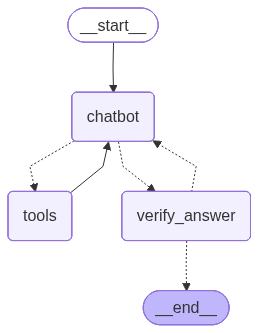

In [13]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not draw graph:", e)

### Run the Agent

In [14]:
def stream_graph_updates(user_input: str):
    print(f"\nUser: {user_input}")
    print("Associate Processing...\n")
    try:
        events = graph.stream(
            {"messages": [("user", user_input)]}, stream_mode="values"
        )
        for event in events:
            event["messages"][-1].pretty_print()

        
        for event in events:
            event["tools_calls"][-1].pretty_print()    
    except Exception as e:
        print(f"Error: {e}")



    print("\n---")

In [15]:
# Example 1: Google Search (Latest News)
stream_graph_updates("What are the latest news about Agentic AI?")


User: What are the latest news about Agentic AI?
Associate Processing...

================================ Human Message =================================

What are the latest news about Agentic AI?
================================== Ai Message ==================================
Tool Calls:
  google_search (fc_0e2f5940-a9ae-4df0-9420-c591dbcfa024)
 Call ID: fc_0e2f5940-a9ae-4df0-9420-c591dbcfa024
  Args:
    query: Agentic AI latest news
================================= Tool Message =================================
Name: google_search

The x402 protocol allows digital agents to use stablecoins so that they can pay for data and products autonomously, moving beyond traditional payment methods. Agentic AI is poised to manage entire workflows in 2026. However, Gartner predicts a reality check, with 40% of projects failing due to high costs and unclear ... Dec 10, 2025 ... ... current processes rather than reimagine workflows for an agentic ... news publication that covered all things AI

In [16]:
# Example 1: Google Search (Latest News)
stream_graph_updates("What are the latest news about us venezuela conflict 2026?")


User: What are the latest news about us venezuela conflict 2026?
Associate Processing...

================================ Human Message =================================

What are the latest news about us venezuela conflict 2026?
================================== Ai Message ==================================
Tool Calls:
  google_search (fc_28ca88db-bf1b-4855-965d-33a26c6b6218)
 Call ID: fc_28ca88db-bf1b-4855-965d-33a26c6b6218
  Args:
    query: US Venezuela conflict 2026 latest news
================================= Tool Message =================================
Name: google_search

Trump Announces U.S. Military's Capture of Maduro. Jan. 3, 2026 | By Matthew Olay, Pentagon News | ... president Trump hegseth secretary of war Venezuela ... Latest News. United States Captures Nicolás Maduro. January 3, 2026. President ... New U.S. Sanctions Targeting Venezuela. December 11, 2025. The United ... 19 hours ago ... Video shows Venezuelan President Nicolas Maduro arriving at the Drug Enforc

In [17]:
# Example 2: Wikipedia (General Knowledge)
stream_graph_updates("What is machine learning?")


User: What is machine learning?
Associate Processing...

================================ Human Message =================================

What is machine learning?
================================== Ai Message ==================================

Machine learning (ML) is a branch of artificial intelligence that focuses on building systems that can learn from data, identify patterns, and make decisions or predictions with minimal human intervention. Instead of being explicitly programmed to perform a task, an ML model is trained on examples—such as images, text, or sensor readings—and it automatically discovers the underlying relationships in the data.

Key aspects of machine learning include:

| Aspect | What it means | Typical techniques |
|--------|---------------|--------------------|
| **Learning from data** | The model improves its performance as it sees more examples. | Supervised, unsupervised, semi‑supervised, reinforcement learning |
| **Pattern recognition** | Detects regula

In [18]:
# Example 3: Arxiv (Research Papers)
stream_graph_updates("Find me a research paper about 'Self-Correction in LLMs'.")


User: Find me a research paper about 'Self-Correction in LLMs'.
Associate Processing...

================================ Human Message =================================

Find me a research paper about 'Self-Correction in LLMs'.
================================== Ai Message ==================================
Tool Calls:
  google_search (fc_4ac1f9fb-c0e7-46d7-8db1-6d44f9ae6bf3)
 Call ID: fc_4ac1f9fb-c0e7-46d7-8db1-6d44f9ae6bf3
  Args:
    query: Self-Correction in LLMs research paper
================================= Tool Message =================================
Name: google_search

This is a collection of research papers for Self-Correcting Large Language Models with Automated Feedback. Our critical survey based on the newly categorized research questions shows that (1) no prior work demonstrates successful self-correction with feedback from ... Feb 26, 2025 ... Some recent papers suggest it is difficult for LLMs to detect their own mistakes, while others claim they are good at corre